# Dataset generation v2

Two labels-only datasets built from FABSA by one pipeline with one flag. Frozen under
`benchmark_outputs/v2/`; `benchmark_builder.ipynb` reads the output.

**Easy**
- All 10 industries x 12 aspects x 3-4 orgs per industry
- Every cell has at least 30 reviews
- Sentiment proportions come from FABSA
- Every question can be answered

**Hard**
- The same 10 x 12 x 3-4 frame
- Cell sizes follow FABSA, so some industry x aspect groups are missing or very small
- Sentiment proportions come from FABSA, identical to Easy
- Some questions have no answer. The agent should report insufficient data rather than make
  unsupported claims

Sparsity is the only difference between them, which is what makes an Easy-to-Hard comparison
attributable to sparsity alone.

In [1]:
import itertools
from collections import namedtuple
from pathlib import Path

import pandas as pd, numpy as np

VERSION = "v2"
SEED    = 29
PREVIEW = "hard"        # both datasets are always built; this only picks the one shown
                        # in the preview cells and the recovery chart: "easy" | "hard"

MIN_REVIEWS = 30              # Easy floor; also the threshold a question needs to be answerable
DROP_RATE   = 0.10            # Hard only: chance an org loses an aspect its industry has (step 5)
SIZE_JITTER = (0.6, 1.4)      # cell size resamples FABSA's volume within this band (step 6)
NEG_LIMITS  = (0.02, 0.95)    # a planted negative rate is kept inside this range (step 4)
MIN_MARGIN  = 0.05            # an org's worst aspect must beat its runner-up by this (step 4)

SENTIMENTS = ["positive", "negative", "neutral"]
OUT_DIR    = Path("../benchmark_outputs") / VERSION
OUT_DIR.mkdir(parents=True, exist_ok=True)
FABSA      = pd.read_csv("clean_fabsa.csv")
print(f"FABSA: {len(FABSA):,} labels | {FABSA.industry.nunique()} industries | "
      f"{FABSA.child_aspect.nunique()} aspects")

FABSA: 13,998 labels | 10 industries | 12 aspects


## Step 1 - Read FABSA's structure

**Do:** group by industry x aspect and record the review count, the sentiment split, and which
cells exist.

In [2]:
counts = (FABSA.groupby(["industry", "child_aspect"]).sentiment.value_counts()
          .unstack(fill_value=0).reindex(columns=SENTIMENTS, fill_value=0))

REVIEW_COUNT = counts.sum(axis=1).to_dict()                        # (industry, aspect) -> reviews
FABSA_SPLIT  = counts.div(counts.sum(axis=1), axis=0).to_dict("index")   #  -> {sentiment: share}
SOURCE_MIX   = FABSA.data_source.value_counts(normalize=True)      # Trustpilot / Play / App Store
PARENT_OF    = dict(FABSA[["child_aspect", "parent_aspect"]].drop_duplicates().to_numpy())

INDUSTRIES = sorted(FABSA.industry.unique())
ASPECTS    = sorted(PARENT_OF)
ALL_CELLS  = [(i, a) for i in INDUSTRIES for a in ASPECTS]         # the full 10 x 12 frame
RECORDED   = [k for k in ALL_CELLS if k in REVIEW_COUNT]
SIZES      = np.array([REVIEW_COUNT[k] for k in RECORDED])

print(f"recorded: {len(RECORDED)}/{len(ALL_CELLS)} industry x aspect cells")
print(f"reviews per cell: min {SIZES.min()}, median {int(np.median(SIZES))}, max {SIZES.max()}, "
      f"{(SIZES < MIN_REVIEWS).sum()} under {MIN_REVIEWS}")
print(counts.sum(axis=1).unstack(fill_value=0).reindex(columns=ASPECTS, fill_value=0).to_string())

recorded: 91/120 industry x aspect cells
reviews per cell: min 3, median 75, max 1024, 28 under 30
child_aspect            account-access  app-website  attitude-of-staff  competitor  discounts-promotions  ease-of-use  email  general-satisfaction  phone  price-value-for-money  reviews  speed
industry                                                                                                                                                                                        
Banking                            125          404                 99          98                     8          353      8                   348      5                    105        3     90
Consulting                          81            0                  0           0                     0            0      0                     0      0                      0        0      0
Fashion                             43          879                234         143                   104          496     31     

## Step 2 - Fill gaps in the sentiment splits

**Do:** where a cell is missing a sentiment - or missing entirely - impute that aspect's average
sentiment distribution across all industries.

In [3]:
ASPECT_SPLIT = (FABSA.groupby("child_aspect").sentiment.value_counts(normalize=True)
                .unstack(fill_value=0).reindex(columns=SENTIMENTS, fill_value=0).to_dict("index"))


def sentiment_split(industry, aspect):
    """FABSA's split for this cell, with anything it never recorded taken from the aspect average."""
    split = FABSA_SPLIT.get((industry, aspect), ASPECT_SPLIT[aspect])
    split = {s: split[s] or ASPECT_SPLIT[aspect][s] for s in SENTIMENTS}
    total = sum(split.values())
    return {s: share / total for s, share in split.items()}


gaps = [(i, a, s) for (i, a), split in FABSA_SPLIT.items() for s in SENTIMENTS if not split[s]]
print(f"whole cells imputed:      {len(ALL_CELLS) - len(RECORDED)}/{len(ALL_CELLS)}")
print(f"single sentiments imputed: {len(gaps)} across {len({(i, a) for i, a, _ in gaps})} cells "
      f"{pd.Series([s for _, _, s in gaps]).value_counts().to_dict()}")
print(pd.DataFrame(ASPECT_SPLIT).T.round(3).to_string())

whole cells imputed:      29/120
single sentiments imputed: 60 across 48 cells {'neutral': 40, 'positive': 15, 'negative': 5}
                       positive  negative  neutral
account-access            0.072     0.598    0.330
app-website               0.553     0.372    0.076
attitude-of-staff         0.580     0.412    0.008
competitor                0.734     0.256    0.010
discounts-promotions      0.567     0.358    0.075
ease-of-use               0.764     0.234    0.002
email                     0.183     0.808    0.008
general-satisfaction      0.783     0.211    0.005
phone                     0.475     0.508    0.017
price-value-for-money     0.748     0.249    0.003
reviews                   0.514     0.469    0.017
speed                     0.715     0.283    0.002


## Step 3 - Add organisations

**Do:** hand-write 3-4 named companies per industry. Fixed, never sampled, so they read naturally
inside a question and stay identical across regenerations.

In [4]:
ORGS = {
    "Banking":                ["Northcrest Bank", "Halden Savings", "Vantor Financial", "Kestrel Bank"],
    "Consulting":             ["Merrow & Pike", "Alderline Advisory", "Castellan Partners"],
    "Fashion":                ["Vella & Co", "Northerly", "Marbrook", "Sable Row"],
    "Groceries":              ["Freshbury", "Larkmead Market", "Oakpan Grocers"],
    "Information Technology": ["Ardent Systems", "Corvex IT", "Bluepath Technologies"],
    "Price Comparison":       ["CompareHive", "Tallywise", "PricePilot"],
    "Ride Hailing":           ["Swiftly Rides", "Kerbside", "Zeta Cabs"],
    "Streaming":              ["Lumora", "Streamly", "Pinecast"],
    "Trading":                ["Northpeak Trading", "Investa", "Quantly"],
    "Travel Booking":         ["Wayfare", "Trippa", "Journeo", "Roamly"],
}
ALL_ORGS = [(industry, org) for industry in INDUSTRIES for org in ORGS[industry]]
assert set(ORGS) == set(INDUSTRIES) and all(3 <= len(o) <= 4 for o in ORGS.values())
print(f"{len(ALL_ORGS)} orgs across {len(INDUSTRIES)} industries -> "
      f"{len(ALL_ORGS) * len(ASPECTS)} cells in the full frame")

33 orgs across 10 industries -> 396 cells in the full frame


## Step 4 - Plant the signal

**Do:** give each org x aspect an offset on its negative rate - mostly zero or small, with one
aspect per org getting the largest offset.

**Why:**
- Without it every org is statistically identical and comparison questions have no answer.
- Designed offsets mean the truth is known in advance rather than discovered from the output.
- Zero offsets give genuine nulls - questions where "no significant difference" is the correct
  answer.
- One large offset per org gives driver-identification questions a clear answer.

**Note:** an org's biggest problem is the aspect with the highest *planted rate*, not the largest
offset - base rates differ by aspect, so a +0.25 on a quiet aspect can still sit below an untouched
noisy one. Gold answers are derived from the rate below, and that is the aspect step 5 protects.

In [5]:
OFFSET_CHOICES = [0.0, 0.05, -0.05, 0.15, -0.15]
MAX_OFFSET     = 0.25

rng, OFFSET = np.random.default_rng(SEED), {}
for industry in INDUSTRIES:
    tied_aspect = str(rng.choice(ASPECTS))               # two orgs will share a zero here
    for org in ORGS[industry]:
        for aspect in ASPECTS:
            OFFSET[org, aspect] = float(rng.choice(OFFSET_CHOICES))
        OFFSET[org, str(rng.choice([a for a in ASPECTS if a != tied_aspect]))] = MAX_OFFSET
    for org in ORGS[industry][:2]:
        OFFSET[org, tied_aspect] = 0.0                   # a genuine null for significance tests


def planted_rate(industry, org, aspect):
    """Where this cell's negative rate is planted: the industry rate plus the org's offset."""
    return float(np.clip(sentiment_split(industry, aspect)["negative"] + OFFSET[org, aspect],
                         *NEG_LIMITS))


# An org's worst aspect has to be an outright winner, or driver-identification questions have no
# single answer -- and cells that hit the 95% ceiling can otherwise land on identical rates. Push
# any close runner-up down, keeping the aspect that was given the largest offset where possible.
for industry, org in ALL_ORGS:
    for _ in range(len(ASPECTS)):
        rates   = {a: planted_rate(industry, org, a) for a in ASPECTS}
        ranked  = sorted(ASPECTS, key=lambda a: (rates[a], OFFSET[org, a] == MAX_OFFSET),
                         reverse=True)
        worst, contenders = ranked[0], [a for a in ranked[1:]
                                        if rates[a] > rates[ranked[0]] - MIN_MARGIN]
        if not contenders:
            break
        for aspect in contenders:
            OFFSET[org, aspect] = min(OFFSET_CHOICES)
        if OFFSET[org, worst] != MAX_OFFSET:          # if that is not enough, promote the leader,
            for aspect in ASPECTS:                    # moving the largest offset rather than adding
                if OFFSET[org, aspect] == MAX_OFFSET:
                    OFFSET[org, aspect] = 0.0
            OFFSET[org, worst] = MAX_OFFSET

PLANTED_RATE    = {(o, a): planted_rate(i, o, a) for i, o in ALL_ORGS for a in ASPECTS}
BIGGEST_PROBLEM = {org: max(ASPECTS, key=lambda a: PLANTED_RATE[org, a]) for _, org in ALL_ORGS}

margins = np.array([np.diff(sorted((PLANTED_RATE[o, a] for a in ASPECTS), reverse=True)[:2])[0]
                    for _, o in ALL_ORGS])
assert (-margins).min() >= MIN_MARGIN, "an org's biggest problem is too close to call"
print(pd.Series(OFFSET).value_counts().sort_index().to_dict())
print(f"biggest problem is the max-offset aspect for "
      f"{sum(OFFSET[o, BIGGEST_PROBLEM[o]] == MAX_OFFSET for _, o in ALL_ORGS)}/{len(ALL_ORGS)} orgs "
      "-- elsewhere a high FABSA base rate wins, and the gold answer follows the rate")
print(f"margin between an org's worst and second-worst aspect: "
      f"min {-margins.max():.3f}, median {-np.median(margins):.3f} (floor {MIN_MARGIN})")

{-0.15: 86, -0.05: 76, 0.0: 89, 0.05: 55, 0.15: 57, 0.25: 33}
biggest problem is the max-offset aspect for 16/33 orgs -- elsewhere a high FABSA base rate wins, and the gold answer follows the rate
margin between an org's worst and second-worst aspect: min 0.050, median 0.161 (floor 0.05)


## Step 5 - Decide which cells exist

**Do:** Easy keeps everything. Hard drops what FABSA never recorded, then randomly drops some
org x aspect combinations.

**Why:**
- This is the only difference between the modes, which is what keeps the comparison clean.
- Dropping at org level is what makes some company-vs-company comparisons impossible.
- An org's biggest-problem aspect is never dropped, or its driver question breaks.

In [6]:
def surviving_cells(mode, rng):
    """Which (industry, org, aspect) cells this mode keeps."""
    kept = []
    for industry, aspect in ALL_CELLS:
        if mode == "hard" and (industry, aspect) not in REVIEW_COUNT:
            continue                                     # FABSA never recorded it
        for org in ORGS[industry]:
            protected = aspect == BIGGEST_PROBLEM[org]
            if mode == "hard" and not protected and rng.random() < DROP_RATE:
                continue                                 # this org loses an aspect its peers have
            kept.append((industry, org, aspect))
    return kept


for mode in ("easy", "hard"):
    kept = surviving_cells(mode, np.random.default_rng(SEED))
    print(f"{mode:5s} {len(kept):4d} cells")

easy   396 cells
hard   285 cells


## Step 6 - Set cell sizes

**Do:** resample the real FABSA volume for that industry x aspect, with some variation. Easy raises
anything under 30; Hard leaves small cells small.

**Why:**
- Resampling observed counts avoids fitting a count model that would need justifying.
- The 30 floor is what makes every Easy question answerable.
- Small cells surviving in Hard is the sparsity the agent has to notice.

In [7]:
def cell_size(industry, aspect, mode, rng):
    """Reviews in this cell: FABSA's volume for the pair, jittered; floored at 30 for Easy."""
    volume = REVIEW_COUNT.get((industry, aspect)) or int(rng.choice(SIZES))
    size   = int(volume * rng.uniform(*SIZE_JITTER))
    return max(size, MIN_REVIEWS) if mode == "easy" else max(size, 1)


# four recorded cells, largest to smallest: Easy lifts the thin ones, Hard keeps them thin.
# Cells FABSA never recorded (e.g. Streaming x email) exist only in Easy, sized from the pool.
demo = np.random.default_rng(SEED)
print(pd.DataFrame([{"industry": i, "aspect": a, "fabsa": REVIEW_COUNT.get((i, a), 0),
                     "easy": cell_size(i, a, "easy", demo), "hard": cell_size(i, a, "hard", demo)}
                    for i, a in [("Banking", "app-website"), ("Groceries", "phone"),
                                 ("Ride Hailing", "reviews"), ("Banking", "reviews")]]
                   ).to_string(index=False))

    industry      aspect  fabsa  easy  hard
     Banking app-website    404   258   406
   Groceries       phone     12    30     9
Ride Hailing     reviews      4    30     2
     Banking     reviews      3    30     2


## Step 7 - Draw the labels

**Do:** take the cell's sentiment split, add the offset to the negative share, rescale the other
two, and draw the counts multinomially. Identical in both modes.

**Why:**
- Random draws make observed rates wobble around planted rates, exactly as real sampling would.
- That wobble is what significance tests exist to see through.
- Because the procedure is identical, any Easy-to-Hard difference is attributable to sparsity.

In [8]:
def build_cells(mode, seed=SEED):
    """One row per surviving cell: its size, what was planted in it, and what was drawn."""
    rng, rows = np.random.default_rng(seed), []
    for industry, org, aspect in surviving_cells(mode, rng):
        split    = sentiment_split(industry, aspect)
        negative = PLANTED_RATE[org, aspect]
        share    = (1 - negative) / (split["positive"] + split["neutral"])
        size     = cell_size(industry, aspect, mode, rng)
        drawn    = rng.multinomial(size, [split["positive"] * share, negative,
                                          split["neutral"] * share])
        rows.append({"industry": industry, "org": org, "child_aspect": aspect,
                     "parent_aspect": PARENT_OF[aspect], "n_reviews": size,
                     "offset": OFFSET[org, aspect],
                     "industry_neg_rate": round(split["negative"], 4),
                     "planted_neg_rate": round(negative, 4),
                     "is_biggest_problem": aspect == BIGGEST_PROBLEM[org],
                     **{s: int(n) for s, n in zip(SENTIMENTS, drawn)}})
    cells = pd.DataFrame(rows)
    cells["observed_neg_rate"] = (cells.negative / cells.n_reviews).round(4)
    cells["over_min_reviews"]  = cells.n_reviews >= MIN_REVIEWS
    return cells


build_cells(PREVIEW).head()

,industry,org,child_aspect,parent_aspect,n_reviews,offset,industry_neg_rate,planted_neg_rate,is_biggest_problem,positive,negative,neutral,observed_neg_rate,over_min_reviews
0,Banking,Halden Savings,account-access,account-management,112,0.00,0.6320,0.6320,False,8,75,29,0.6696,True
1,Banking,Vantor Financial,account-access,account-management,108,-0.15,0.6320,0.4820,False,8,52,48,0.4815,True
2,Banking,Kestrel Bank,account-access,account-management,90,-0.05,0.6320,0.5820,False,5,61,24,0.6778,True
3,Banking,Northcrest Bank,app-website,online-experience,401,-0.05,0.2748,0.2248,False,203,100,98,0.2494,True
4,Banking,Vantor Financial,app-website,online-experience,289,-0.15,0.2748,0.1248,False,164,34,91,0.1176,True


## Step 8 - Write two files

**Do:** `labels.csv`, one row per review with no text; `cells.csv`, the planted rates, offsets and
cell sizes.

**Why:**
- The agent reads the first and the scorer reads the second, so ground truth cannot leak.
- No review text, because no tool reads one - generating it would cost days and change no metric.

In [9]:
def to_labels(cells, seed=SEED):
    """Expand cell counts into one row per review, shuffled, with an id and a source."""
    rng  = np.random.default_rng(seed)
    long = cells.melt(["industry", "org", "parent_aspect", "child_aspect"], SENTIMENTS,
                      var_name="sentiment", value_name="n")
    labels = (long.loc[long.index.repeat(long.n)].drop(columns="n")
              .sample(frac=1, random_state=seed).reset_index(drop=True))
    labels.insert(0, "review_id", [f"R{i:06d}" for i in range(1, len(labels) + 1)])
    labels["data_source"] = rng.choice(SOURCE_MIX.index, len(labels), p=SOURCE_MIX.values)
    return labels[["review_id", "industry", "org", "parent_aspect", "child_aspect",
                   "sentiment", "data_source"]]


DATASETS = {}
for mode in ("easy", "hard"):
    cells  = build_cells(mode)
    labels = to_labels(cells)
    folder = OUT_DIR / mode
    folder.mkdir(exist_ok=True)
    labels.to_csv(folder / "labels.csv", index=False)          # the agent reads this
    cells.to_csv(folder / "cells.csv", index=False)            # the scorer reads this
    DATASETS[mode] = (labels, cells)
    print(f"{mode:5s} -> {len(cells):4d} cells | {len(labels):6,d} reviews | "
          f"{cells.over_min_reviews.mean():.0%} of cells over {MIN_REVIEWS} reviews")

pd.DataFrame([{"industry": i, "org": o, "child_aspect": a, "offset": OFFSET[o, a],
               "planted_neg_rate": round(PLANTED_RATE[o, a], 4),
               "is_biggest_problem": a == BIGGEST_PROBLEM[o]}
              for i, o in ALL_ORGS for a in ASPECTS]).to_csv(OUT_DIR / "offsets.csv", index=False)
DATASETS[PREVIEW][0].head()

easy  ->  396 cells | 62,817 reviews | 100% of cells over 30 reviews
hard  ->  285 cells | 42,343 reviews | 67% of cells over 30 reviews


,review_id,industry,org,parent_aspect,child_aspect,sentiment,data_source
0,R000001,Fashion,Sable Row,company-brand,general-satisfaction,positive,Google Play
1,R000002,Price Comparison,Tallywise,purchase-booking-experience,ease-of-use,negative,Google Play
2,R000003,Fashion,Sable Row,logistics-rides,speed,positive,Google Play
3,R000004,Fashion,Marbrook,company-brand,general-satisfaction,positive,Google Play
4,R000005,Fashion,Sable Row,company-brand,general-satisfaction,positive,Google Play


## Step 9 - Validate

- **Fidelity** - overlay synthetic against FABSA on aspect prevalence, sentiment split and cell
  sizes. Ordering and imbalance should track; exact values should not, because that gap is the
  planted signal.
- **Recovery** - regress the observed negative-rate shift on the planted offset. A slope near 1
  proves the generator does what it claims, which is what makes the ground truth credible.
- **Sparsity contrast** - Hard should keep roughly 60-75% of Easy's cells, with a non-trivial share
  under 30 reviews. Meaningfully sparser, not gutted.
- **Log it** - the numbers go to `validation_report.txt` beside the frozen dataset.

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

FIG_DIR = Path("../figures"); FIG_DIR.mkdir(exist_ok=True)
REAL, EASY, HARD = "#2a78d6", "#eb6834", "#1baf7a"      # validated categorical slots 1-3
INK, GRID = "#52514e", "#e1e0d9"
plt.rcParams.update({"figure.dpi": 140, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "axes.edgecolor": "#c3c2b7",
                     "xtick.color": INK, "ytick.color": INK, "xtick.labelsize": 9,
                     "ytick.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False})

def style(ax, axis="y", title=""):
    ax.grid(axis=axis, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True); ax.tick_params(length=0)
    ax.set_title(title, loc="left", fontsize=10.5, pad=8)
    return ax


LABELS, CELLS = DATASETS[PREVIEW]

In [11]:
from scipy.stats import spearmanr

report = []
def log(line=""):
    report.append(line)
    print(line)


# ---- fidelity ----------------------------------------------------------------------------
log(f"dataset generation {VERSION} | seed {SEED} | drop_rate {DROP_RATE}")
log()
log("FIDELITY (rank agreement with FABSA; exact values are meant to differ)")
grid  = pd.MultiIndex.from_product([INDUSTRIES, ASPECTS])
fabsa_size    = FABSA.groupby(["industry", "child_aspect"]).size().reindex(grid, fill_value=0)
fabsa_aspects = FABSA.child_aspect.value_counts(normalize=True).reindex(ASPECTS)
for mode, (labels, cells) in DATASETS.items():
    size    = labels.groupby(["industry", "child_aspect"]).size().reindex(grid, fill_value=0)
    aspects = labels.child_aspect.value_counts(normalize=True).reindex(ASPECTS).fillna(0)
    log(f"  {mode:5s} cell size rank {spearmanr(fabsa_size, size).statistic:.2f} | "
        f"aspect mix rank {spearmanr(fabsa_aspects, aspects).statistic:.2f} | "
        f"negative {labels.sentiment.eq('negative').mean():.1%} vs FABSA "
        f"{FABSA.sentiment.eq('negative').mean():.1%}")

# ---- recovery ----------------------------------------------------------------------------
log()
log("RECOVERY (observed shift regressed on planted offset; 1.00 = generator did what it claims)")
for mode, (_, cells) in DATASETS.items():
    scored  = cells[cells.over_min_reviews]
    clipped = (scored.industry_neg_rate + scored.offset - scored.planted_neg_rate).abs() > 1e-6
    slope, _ = np.polyfit(scored.offset[~clipped],
                          (scored.observed_neg_rate - scored.industry_neg_rate)[~clipped], 1)
    log(f"  {mode:5s} slope {slope:.3f} over {(~clipped).sum()} cells "
        f"({clipped.sum()} excluded: too near the {NEG_LIMITS[0]:.0%}-{NEG_LIMITS[1]:.0%} limits)")

# ---- sparsity contrast --------------------------------------------------------------------
log()
log("SPARSITY CONTRAST (Hard against Easy)")
easy_cells, hard_cells = DATASETS["easy"][1], DATASETS["hard"][1]
retained = len(hard_cells) / len(easy_cells)
thin     = (~hard_cells.over_min_reviews).mean()
log(f"  cells retained {len(hard_cells)}/{len(easy_cells)} = {retained:.1%} (target 60-75%)")
log(f"  hard cells under {MIN_REVIEWS} reviews: {thin:.1%} | reviews "
    f"{len(DATASETS['hard'][0]):,} vs {len(DATASETS['easy'][0]):,}")
log(f"  industry x aspect groups missing from hard: "
    f"{(hard_cells.groupby(['industry', 'child_aspect']).size().reindex(grid).isna()).sum()}"
    f"/{len(grid)}")
assert 0.60 <= retained <= 0.75, f"retention {retained:.1%} outside the 60-75% target"
assert thin > 0.05, "hard has almost no thin cells -- it is not meaningfully sparser"

(OUT_DIR / "validation_report.txt").write_text("\n".join(report) + "\n")
print()
print(f"wrote {OUT_DIR / 'validation_report.txt'}")

dataset generation v2 | seed 29 | drop_rate 0.1

FIDELITY (rank agreement with FABSA; exact values are meant to differ)
  easy  cell size rank 0.57 | aspect mix rank 0.93 | negative 32.7% vs FABSA 31.2%
  hard  cell size rank 0.99 | aspect mix rank 0.99 | negative 32.6% vs FABSA 31.2%

RECOVERY (observed shift regressed on planted offset; 1.00 = generator did what it claims)
  easy  slope 0.976 over 364 cells (32 excluded: too near the 2%-95% limits)
  hard  slope 1.047 over 181 cells (10 excluded: too near the 2%-95% limits)

SPARSITY CONTRAST (Hard against Easy)
  cells retained 285/396 = 72.0% (target 60-75%)
  hard cells under 30 reviews: 33.0% | reviews 42,343 vs 62,817
  industry x aspect groups missing from hard: 29/120

wrote ..\benchmark_outputs\v2\validation_report.txt


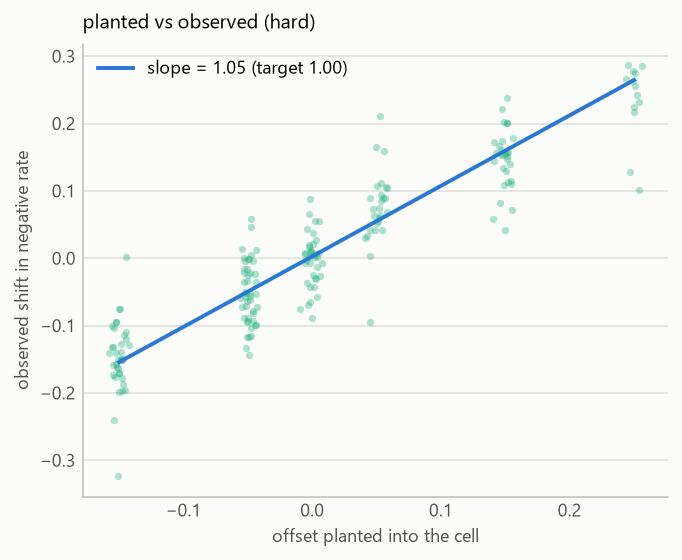

In [12]:
# recovery, drawn: does each cell move by as much as was planted into it?
colour  = EASY if PREVIEW == "easy" else HARD          # colour follows the dataset
scored  = CELLS[CELLS.over_min_reviews]
shift   = scored.observed_neg_rate - scored.industry_neg_rate
clipped = (scored.industry_neg_rate + scored.offset - scored.planted_neg_rate).abs() > 1e-6
slope, intercept = np.polyfit(scored.offset[~clipped], shift[~clipped], 1)

fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.scatter(scored.offset + np.random.default_rng(0).normal(0, .004, len(scored)), shift,
           s=14, color=colour, alpha=.35, lw=0, zorder=3)
edges = np.array([scored.offset.min(), scored.offset.max()])
ax.plot(edges, slope * edges + intercept, color=REAL, lw=2, zorder=4,
        label=f"slope = {slope:.2f} (target 1.00)")
style(ax, title=f"planted vs observed ({PREVIEW})").legend(frameon=False, fontsize=9)
ax.set_xlabel("offset planted into the cell", fontsize=9, color=INK)
ax.set_ylabel("observed shift in negative rate", fontsize=9, color=INK)
fig.savefig(FIG_DIR / f"recovery_{VERSION}_{PREVIEW}.png", bbox_inches="tight")

## Step 10 - Freeze

**Do:** fixed seed, versioned outputs, one config file carrying every parameter.

**Why:** one script and one flag produce both modes, so "same process, different sparsity" is
checkable rather than asserted.

In [13]:
import yaml

CONFIG = {
    "version": VERSION, "seed": SEED, "source": "clean_fabsa.csv",
    "min_reviews": MIN_REVIEWS, "drop_rate": DROP_RATE,
    "size_jitter": list(SIZE_JITTER), "neg_limits": list(NEG_LIMITS),
    "offsets": OFFSET_CHOICES + [MAX_OFFSET],
    "industries": INDUSTRIES, "aspects": ASPECTS, "parent_of": PARENT_OF, "orgs": ORGS,
    "cells": {mode: len(cells) for mode, (_, cells) in DATASETS.items()},
    "reviews": {mode: len(labels) for mode, (labels, _) in DATASETS.items()},
    "outputs": {"agent_sees": "{mode}/labels.csv", "scorer_sees": "{mode}/cells.csv",
                "ground_truth": "offsets.csv", "validation": "validation_report.txt"},
}
(OUT_DIR / "generation_config.yaml").write_text(yaml.safe_dump(CONFIG, sort_keys=False))
print(f"froze {VERSION}: {sorted(p.name for p in OUT_DIR.iterdir())}")

froze v2: ['easy', 'generation_config.yaml', 'hard', 'offsets.csv', 'validation_report.txt']


## Aspect and sentiment distributions: FABSA vs Easy vs Hard

One run produces both datasets, so they can be read side by side against the source.

- **Aspect prevalence** shows what sparsity costs. Easy tracks FABSA loosely because its 30-review
  floor inflates every thin aspect; Hard tracks it closely because it inherits FABSA's volumes.
- **Sentiment split** should be close in both. The negative share runs a little above FABSA in each,
  which is the planted offsets showing up: they are net positive by design, since every org gets one
  large positive offset for its biggest problem.

child_aspect (% of reviews, and the gap in percentage points)
                       FABSA  easy  hard  easy - FABSA  hard - FABSA
child_aspect                                                        
account-access           3.4   2.7   3.1          -0.7          -0.3
app-website             26.1  20.5  26.9          -5.6           0.8
attitude-of-staff        7.7   7.2   7.6          -0.6          -0.1
competitor               4.4   6.5   4.4           2.1          -0.0
discounts-promotions     2.9   3.2   2.9           0.3           0.1
ease-of-use             16.9  15.9  13.9          -1.0          -3.0
email                    0.9   1.8   0.9           0.9           0.0
general-satisfaction    20.8  18.9  24.0          -1.9           3.3
phone                    1.3   2.4   1.5           1.1           0.2
price-value-for-money    7.3   8.9   7.2           1.6          -0.1
reviews                  1.3   4.6   1.5           3.3           0.2
speed                    7.2   7.6   6.2 

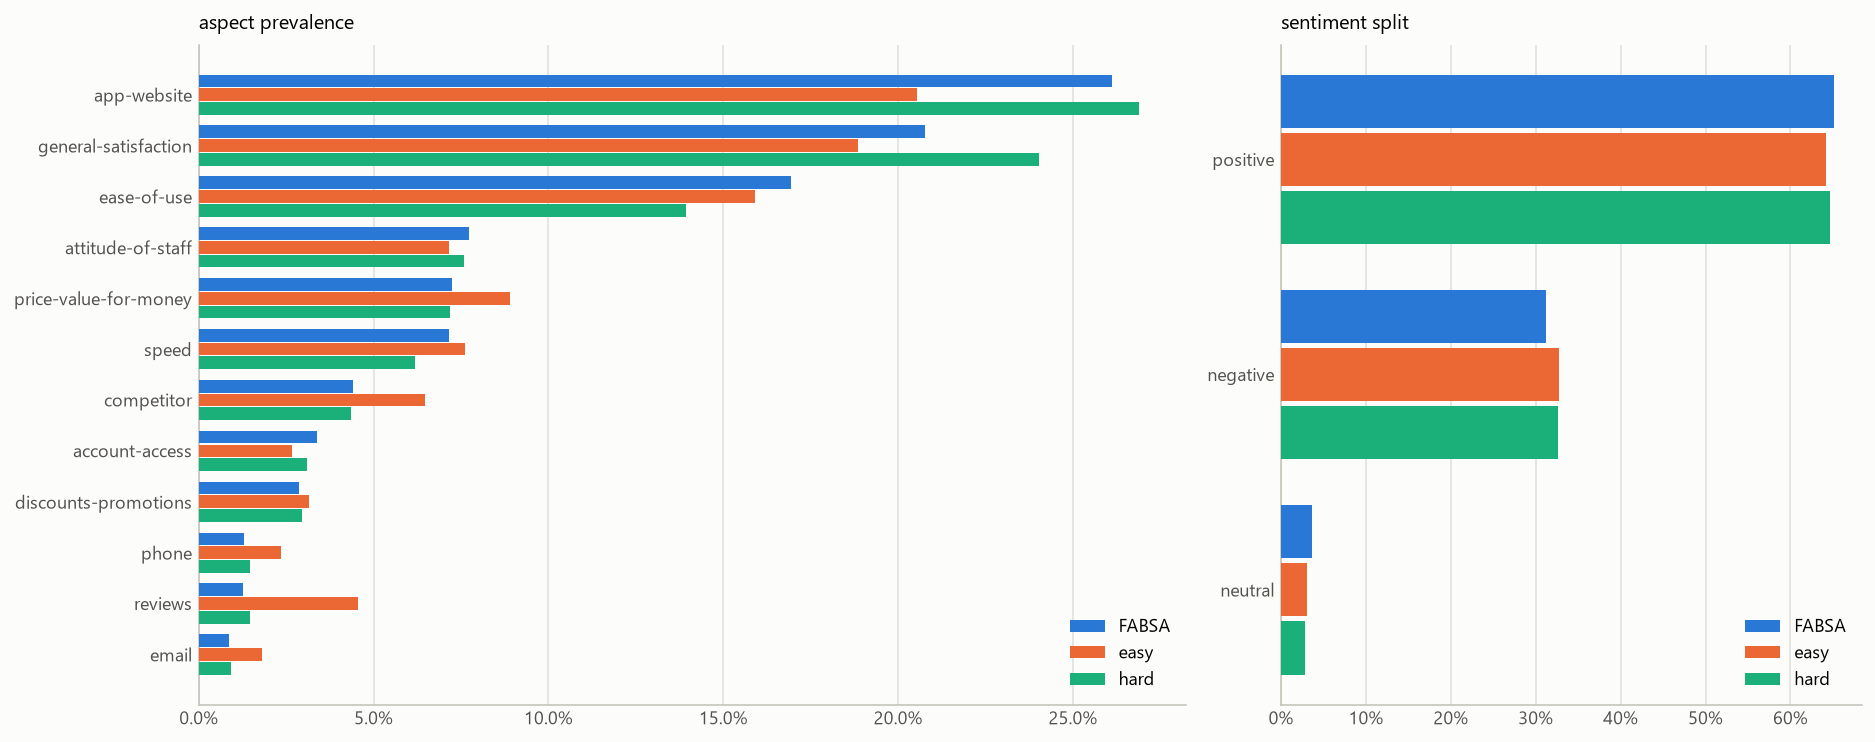

In [14]:
def shares(labels, column, order):
    return labels[column].value_counts(normalize=True).reindex(order).fillna(0)


series = [("FABSA", FABSA, REAL), ("easy", DATASETS["easy"][0], EASY),
          ("hard", DATASETS["hard"][0], HARD)]
aspect_order = shares(FABSA, "child_aspect", ASPECTS).sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), gridspec_kw={"width_ratios": [1.7, 1]})
for ax, (column, order, title) in zip(axes, [("child_aspect", aspect_order, "aspect prevalence"),
                                             ("sentiment", SENTIMENTS[::-1], "sentiment split")]):
    y = np.arange(len(order))
    for slot, (name, labels, colour) in enumerate(series):
        ax.barh(y + (1 - slot) * 0.27, shares(labels, column, order), 0.25,
                color=colour, label=name, zorder=3)
    ax.set_yticks(y, order, fontsize=9)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    style(ax, axis="x", title=title).legend(frameon=False, fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / f"distributions_{VERSION}.png", bbox_inches="tight")

for column, order in [("child_aspect", ASPECTS), ("sentiment", SENTIMENTS)]:
    table = pd.DataFrame({name: shares(labels, column, order) for name, labels, _ in series}) * 100
    table["easy - FABSA"] = (table.easy - table.FABSA).round(1)
    table["hard - FABSA"] = (table.hard - table.FABSA).round(1)
    print(f"{column} (% of reviews, and the gap in percentage points)")
    print(table.round(1).to_string(), end="\n\n")

## Per-industry breakdown

The same comparison split by industry. The aggregate above can hide a mode that tracks FABSA
overall while distorting individual industries, which is where the questions are actually asked.

- **Aspect prevalence** is a share of that industry's own reviews, so each panel sums to 100%.
  Panels carry their own x-scale: the industries FABSA barely covers sit on one or two aspects and
  would flatten a shared axis. Hard should hug FABSA; Easy should spread wider, because its
  30-review floor invents the aspects FABSA never recorded.
- **Sentiment split** shares one x-scale across all three panels, since all three sentiments are
  shares of the same denominator. Both modes should sit close to FABSA, with negative running
  slightly high - the planted offsets are net positive by design.

**Read both with Consulting, Information Technology and Streaming set aside.** FABSA records 1-3
aspects for them and labels 91-100% of those reviews neutral, so there is no aspect mix and no
positive/negative baseline there to be faithful to. Hard inherits the degeneracy; Easy imputes
past it from the aspect averages. Their gaps dominate any average that includes them, so the
summaries below report the seven covered industries separately from these three.

aspect-mix distance from FABSA, per industry (0 = identical, 1 = no overlap)
                        fabsa_aspects   easy   hard
Banking                            12  0.057  0.078
Consulting                          1  0.940  0.000
Fashion                            12  0.053  0.086
Groceries                          12  0.055  0.078
Information Technology              3  0.903  0.080
Price Comparison                   12  0.045  0.065
Ride Hailing                       12  0.136  0.028
Streaming                           3  0.912  0.011
Trading                            12  0.049  0.083
Travel Booking                     12  0.049  0.046

7 industries FABSA covers fully: easy 0.063 | hard 0.066
Consulting, Information Technology, Streaming (1-3 aspects recorded): easy 0.918 | hard 0.030
the second line is Easy's 30-review floor inventing aspects FABSA never recorded -- by design, but it is why aggregate fidelity should be read off the first


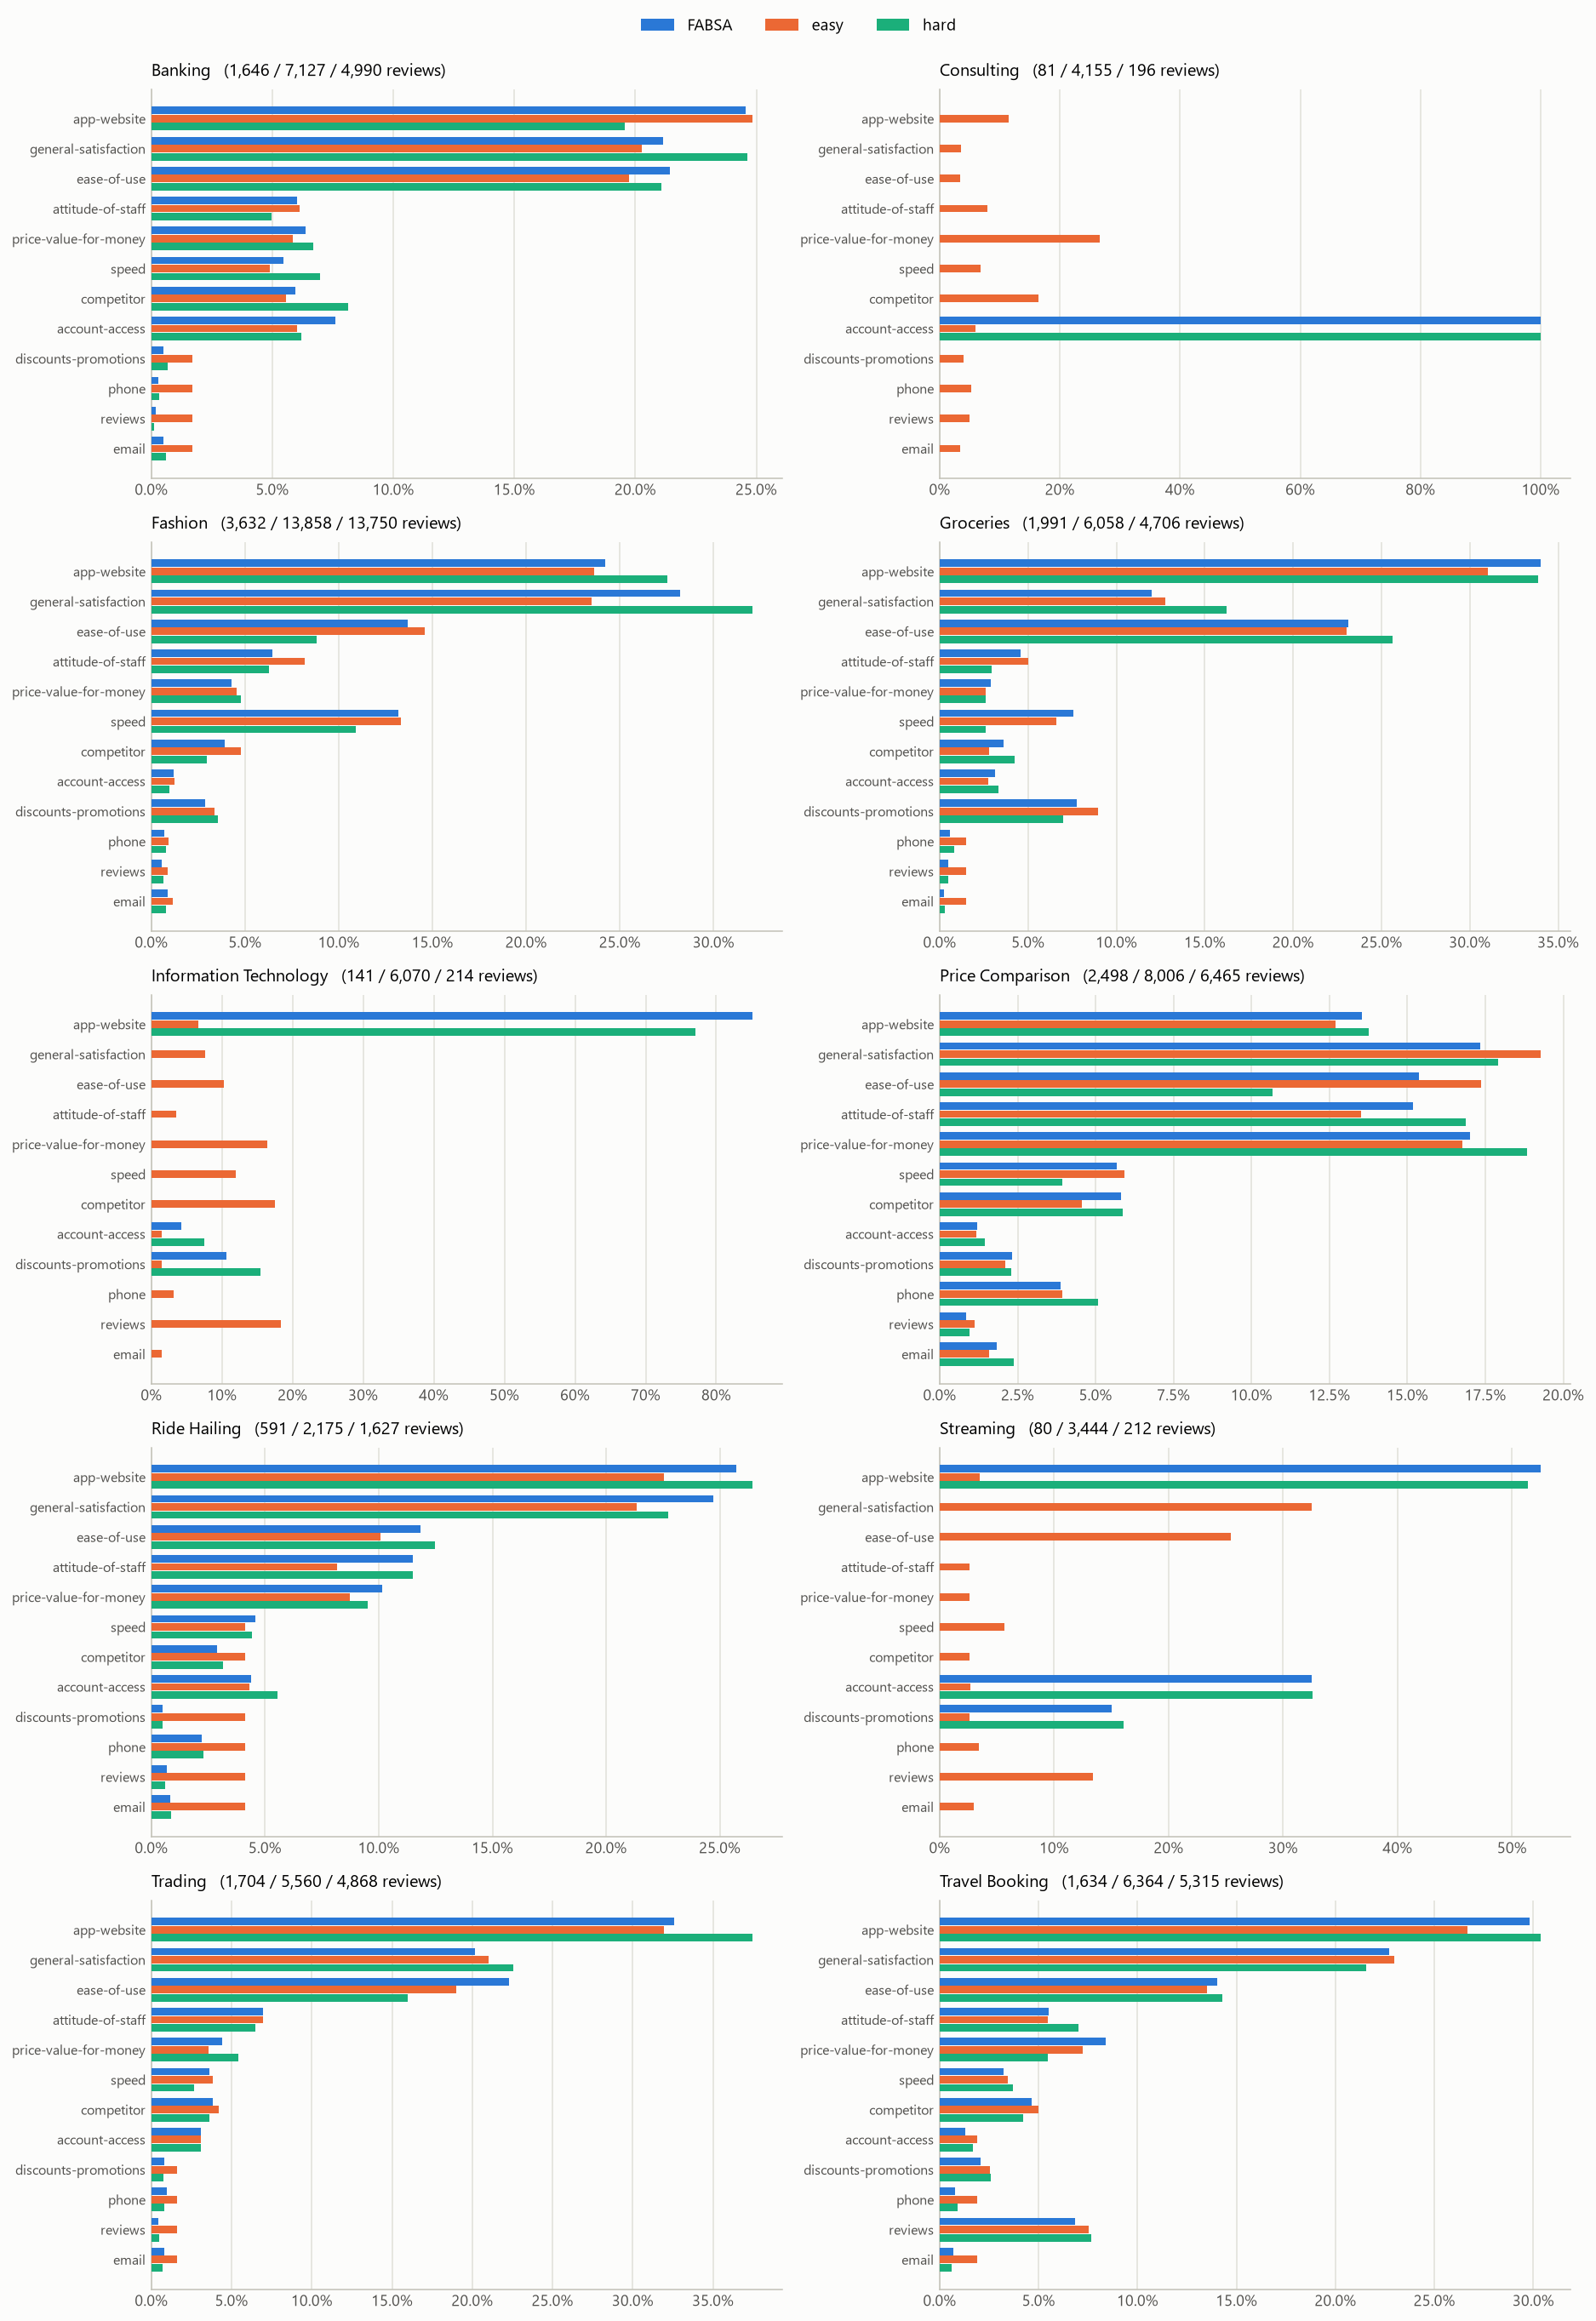

In [15]:
def industry_shares(labels, industry, column, order):
    """How this industry's reviews divide across `order` -- zero where the value never appears."""
    rows = labels[labels.industry == industry]
    return rows[column].value_counts(normalize=True).reindex(order).fillna(0)


fig, axes = plt.subplots(5, 2, figsize=(13.5, 19.5))
for ax, industry in zip(axes.ravel(), INDUSTRIES):
    y = np.arange(len(aspect_order))
    for slot, (name, labels, colour) in enumerate(series):
        ax.barh(y + (1 - slot) * 0.27,
                industry_shares(labels, industry, "child_aspect", aspect_order),
                0.25, color=colour, label=name, zorder=3)
    ax.set_yticks(y, aspect_order, fontsize=8)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    sizes = " / ".join(f"{(labels.industry == industry).sum():,}" for _, labels, _ in series)
    style(ax, axis="x", title=f"{industry}   ({sizes} reviews)")

fig.tight_layout(rect=(0, 0, 1, 0.982))
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=3,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, 1.0))
fig.savefig(FIG_DIR / f"aspects_by_industry_{VERSION}.png", bbox_inches="tight")

# How far each mode's aspect mix sits from FABSA's, per industry: total variation distance --
# the share of reviews that would have to move to another aspect to match FABSA exactly.
drift = pd.DataFrame(
    {mode: [(industry_shares(labels, i, "child_aspect", ASPECTS)
             - industry_shares(FABSA, i, "child_aspect", ASPECTS)).abs().sum() / 2
            for i in INDUSTRIES] for mode, (labels, _) in DATASETS.items()},
    index=INDUSTRIES)
drift.insert(0, "fabsa_aspects", FABSA.groupby("industry").child_aspect.nunique())

# Three industries sit on 1-3 aspects in FABSA, so there is barely a mix there to match. They are
# reported apart, or they carry an average that says nothing about the seven that are covered.
SPARSE  = [i for i in INDUSTRIES if drift.fabsa_aspects[i] < len(ASPECTS)]
covered = drift.drop(index=SPARSE)
print("aspect-mix distance from FABSA, per industry (0 = identical, 1 = no overlap)")
print(drift.round(3).to_string())
print(f"\n{len(covered)} industries FABSA covers fully: "
      f"easy {covered.easy.mean():.3f} | hard {covered.hard.mean():.3f}")
print(f"{', '.join(SPARSE)} ({drift.fabsa_aspects[SPARSE].min()}-"
      f"{drift.fabsa_aspects[SPARSE].max()} aspects recorded): "
      f"easy {drift.loc[SPARSE].easy.mean():.3f} | hard {drift.loc[SPARSE].hard.mean():.3f}")
print("the second line is Easy's 30-review floor inventing aspects FABSA never recorded -- "
      "by design, but it is why aggregate fidelity should be read off the first")

sentiment split by industry (% of that industry's reviews)
                          FABSA                      easy                      hard                 
sentiment              positive negative neutral positive negative neutral positive negative neutral
Banking                    61.8     29.8     8.4     57.3     34.2     8.5     63.5     28.7     7.9
Consulting                  0.0      0.0   100.0     62.6     32.9     4.5      3.1     37.8    59.2
Fashion                    72.3     27.5     0.2     70.3     29.0     0.7     70.6     28.7     0.8
Groceries                  57.4     41.6     1.1     57.1     40.0     2.9     58.1     39.5     2.5
Information Technology      0.0      1.4    98.6     67.6     25.5     6.8     33.2     10.7    56.1
Price Comparison           77.5     22.1     0.5     76.4     23.1     0.5     73.9     25.6     0.5
Ride Hailing               19.5     77.8     2.7     22.5     73.4     4.1     22.1     73.3     4.6
Streaming                   0.0 

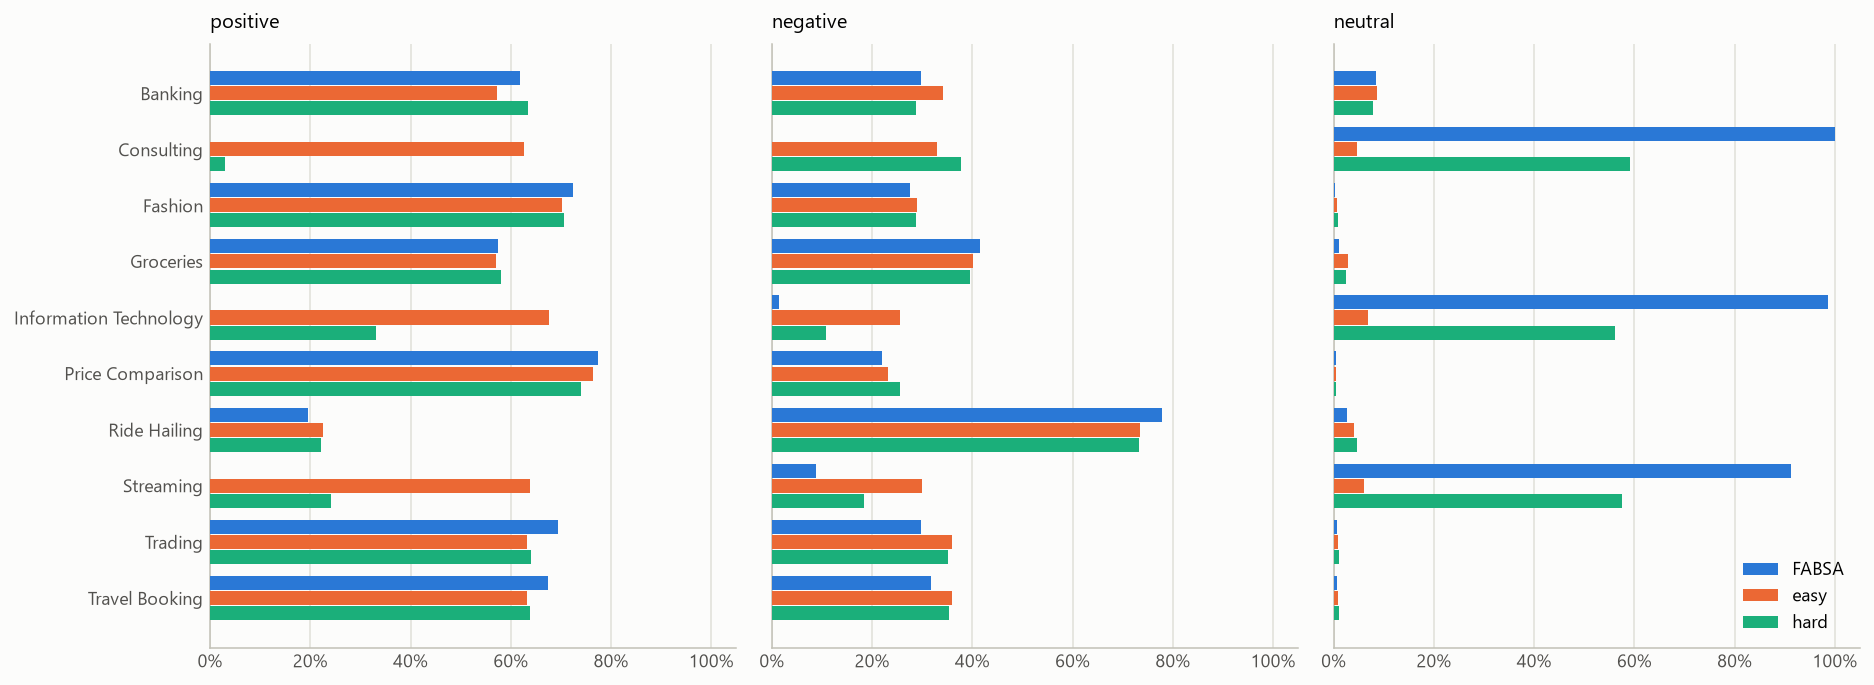

In [16]:
order = INDUSTRIES[::-1]                      # barh fills upward; reversed reads alphabetically
y     = np.arange(len(order))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.0), sharex=True)
for ax, sentiment in zip(axes, SENTIMENTS):
    for slot, (name, labels, colour) in enumerate(series):
        ax.barh(y + (1 - slot) * 0.27,
                [industry_shares(labels, i, "sentiment", SENTIMENTS)[sentiment] for i in order],
                0.25, color=colour, label=name, zorder=3)
    ax.set_yticks(y, order if ax is axes[0] else [], fontsize=9)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    style(ax, axis="x", title=sentiment)
axes[-1].legend(frameon=False, fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / f"sentiment_by_industry_{VERSION}.png", bbox_inches="tight")

split = pd.concat({name: pd.DataFrame(
    [industry_shares(labels, i, "sentiment", SENTIMENTS) for i in INDUSTRIES], index=INDUSTRIES)
    for name, labels, _ in series}, axis=1) * 100
print("sentiment split by industry (% of that industry's reviews)")
print(split.round(1).to_string())

# The same three industries again: FABSA labels them almost entirely neutral, so there is no
# positive/negative baseline to match and their gap says nothing about how faithful a mode is.
for mode in ("easy", "hard"):
    gaps = (split[mode].negative - split.FABSA.negative).abs().drop(SPARSE)
    print(f"\n{mode:5s} negative-share gap vs FABSA over the {len(gaps)} covered industries: "
          f"max {gaps.max():.1f}pp ({gaps.idxmax()}), mean {gaps.mean():.1f}pp")
print(f"\nexcluded: {', '.join(SPARSE)} -- FABSA labels them "
      f"{split.FABSA.neutral[SPARSE].min():.0f}-{split.FABSA.neutral[SPARSE].max():.0f}% neutral. "
      "Hard inherits that, Easy imputes past it")